# V0.1 — Homogenization bound validity & tightness *(the keystone)*

**Tier 0 / Verification Protocol §V0.1.** Targets architecture **Decision #15** and the *"ONE SCALAR, FOUR JOBS"* claim (`AGENT/ARCHITECTURE.md` §III.4).

### Claim (falsifiable)
For a heterogeneous cell (bark + sapwood + heartwood, ± a char wedge), the homogenized effective-stiffness estimate lies **within** the Voigt–Reuss gap in every direction, and for quiescent (low-contrast) cells the gap is tight enough to be useful.

### Load-bearing because
This single scalar gates refinement, conservation tolerance, surrogate trust, and LOD. If the bound is **violated**, the trust signal is meaningless; if it is **always loose**, everything refines and the efficiency thesis dies.

### Oracle (independent ground truth)
A direct fine-scale solve (**DNS**) of the fully-resolved heterogeneous cell under prescribed strains → the *true* effective stiffness tensor. Built in `src/verification/oracles/dns_elasticity_3d.py` (3D voxel periodic homogenization), itself validated against the closed-form Backus laminate in `analytic.py`. *The expensive reference exists so the cheap production path never has to be trusted on faith.*

### Pre-registered pass criteria (frozen before running)
| # | Metric | Threshold | Nature | Failure → outcome |
|---|---|---|---|---|
| 1 | DNS within `[Reuss, Voigt]` per direction | **100%** of cells & directions | theorem-check | **KILL** (theory/impl error) |
| 2 | Layered principal-direction residual (bound-exact channels) | **< 1%** | empirical | REDESIGN basis |
| 3 | Relative gap on **low-contrast** cells | **< 30%** for **> 80%** of cells | empirical | **REDESIGN** (Hashin–Shtrikman / measured-RVE) |

A red result is a *result*, not a setback — it redirects the architecture record while it is still cheap to move.

In [1]:
"""(1) Setup — imports, paths, frozen thresholds, deterministic seed."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# make the shared oracle modules importable (notebook lives in verification_notebooks/phase0/)
REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))

import dns_elasticity_3d as _dns
from dns_elasticity_3d import effective_stiffness
from homogenization import (voigt_bound, reuss_bound, relative_gap,
                            containment, directional_estimate, DIR_LABELS)
from analytic import laminate_stiffness, layered_exact_channels
import cells

np.set_printoptions(precision=3, suppress=True)
np.random.seed(0)                       # determinism (protocol V0.5 discipline)

# ---- PRE-REGISTERED pass criteria (frozen) ----
CONTAINMENT_TOL      = 1e-9            # numerical slack on the bracketing theorem
LAYERED_EXACT_TOL    = 0.01           # < 1% residual on bound-exact channels
TIGHTNESS_GAP        = 0.30           # gap must be < 30% ...
TIGHTNESS_COVERAGE   = 0.80           # ... for > 80% of low-contrast cells
LOW_CONTRAST_MAX     = 3.0            # a cell is "quiescent" if max phase ratio <= 3
DET_TOL              = 1e-9           # GPU CG reproducibility regime (protocol V0.5)

N = 24                                 # DNS voxel resolution per axis (3*N^3 DOF)
print(f"repo = {REPO}")
print(f"DNS backend = {'GPU (cupy CG)' if _dns._HAS_GPU else 'CPU (sparse LU)'}")
print(f"DNS resolution N = {N}  ({3*N**3} DOF per solve)")


repo = /workspace/nebula
DNS backend = GPU (cupy CG)
DNS resolution N = 24  (41472 DOF per solve)


## (2) Validate the oracle *before trusting it*

The DNS solver is only ground truth if it is itself correct. Two checks gate it:
- **Homogeneous identity:** a single-phase cell must return exactly its own stiffness (`C_eff == C_phase`).
- **Backus closed form:** a clean layered stack must match the analytic transversely-isotropic laminate to solver tolerance.

If either fails, every downstream number is meaningless and we stop here.

In [2]:
"""(2) Oracle validation: homogeneous identity + DNS-vs-Backus on layered cells."""
from homogenization import isotropic_stiffness

# 2a. homogeneous identity
hc = cells.homogeneous_cell(n=N, E=10.0, nu=0.3)
C_dns = effective_stiffness(hc.grid, hc.materials)
C_true = isotropic_stiffness(10.0, 0.3)
homog_err = np.linalg.norm(C_dns - C_true) / np.linalg.norm(C_true)
print(f"2a) homogeneous identity   : rel err = {homog_err:.2e}")

# 2b. DNS vs analytic Backus laminate, across a few contrasts & orientations
print("2b) DNS vs Backus laminate :")
backus_errs = []
for contrast in (2.0, 10.0, 50.0):
    for axis in (0, 1, 2):
        c = cells.two_phase_layered(n=N, frac_stiff=0.5, contrast=contrast, axis=axis)
        moduli = [m[0] for m in c.materials]
        nus = [m[1] for m in c.materials]
        C_dns = effective_stiffness(c.grid, c.materials)
        C_ana = laminate_stiffness(c.fractions, moduli, nus, axis)
        err = np.linalg.norm(C_dns - C_ana) / np.linalg.norm(C_ana)
        backus_errs.append(err)
        print(f"     contrast={contrast:5.1f}  axis={axis}   rel err = {err:.2e}")

ORACLE_OK = (homog_err < 1e-10) and (max(backus_errs) < 1e-10)
print(f"\n   => ORACLE TRUSTWORTHY: {ORACLE_OK}  "
      f"(homog {homog_err:.1e}, max backus {max(backus_errs):.1e})")
assert ORACLE_OK, "DNS oracle failed self-validation — halt; do not interpret V0.1."


2a) homogeneous identity   : rel err = 9.81e-14
2b) DNS vs Backus laminate :


     contrast=  2.0  axis=0   rel err = 7.65e-14


     contrast=  2.0  axis=1   rel err = 4.15e-14


     contrast=  2.0  axis=2   rel err = 4.77e-14


     contrast= 10.0  axis=0   rel err = 6.05e-14


     contrast= 10.0  axis=1   rel err = 5.14e-14


     contrast= 10.0  axis=2   rel err = 3.14e-14


     contrast= 50.0  axis=0   rel err = 5.69e-14


     contrast= 50.0  axis=1   rel err = 7.88e-14


     contrast= 50.0  axis=2   rel err = 8.78e-14

   => ORACLE TRUSTWORTHY: True  (homog 9.8e-14, max backus 8.8e-14)


## (3) Build the cell battery

Two families spanning the sweep (intact wood ↔ heavy char):
- **Family A — layered** (the "concentric tree shells" case): two-phase stacks at contrasts `1.2 → 100` along each of the 3 principal axes, plus a 3-phase bark/sapwood/heartwood cell. Gives the layered-exactness and tightness populations.
- **Family B — char wedge** (the structurally-critical case): a char wedge of varying depth and contrast intruding into wood. High-contrast; reused by V0.2.

Each cell is tagged **low-contrast** (quiescent) iff its max phase stiffness ratio ≤ 3.

In [3]:
"""(3) Construct the cell battery."""
battery = []   # list of (label, Cell)

# Family A — layered two-phase sweep (contrast x orientation)
CONTRASTS = [1.2, 1.5, 2.0, 2.5, 3.0, 5.0, 10.0, 30.0, 100.0]
for contrast in CONTRASTS:
    for axis in (0, 1, 2):
        c = cells.two_phase_layered(n=N, frac_stiff=0.5, contrast=contrast, axis=axis)
        battery.append((f"layered c={contrast:g} ax{axis}", c))

# Family A — realistic 3-phase tree shells (bark / sapwood / heartwood) along each axis
for axis in (0, 1, 2):
    battery.append((f"tree-shells ax{axis}", cells.layered_cell(n=N, axis=axis)))

# Family B — char wedge (depth x contrast); high-contrast, structurally critical
for depth in (0.3, 0.5, 0.7):
    for contrast in (30.0, 60.0, 100.0):
        c = cells.char_wedge_cell(n=N, depth=depth, contrast=contrast)
        battery.append((f"char-wedge d={depth:g} c={contrast:g}", c))

n_low = sum(c.low_contrast for _, c in battery)
print(f"built {len(battery)} cells: "
      f"{sum(c.kind=='layered' for _,c in battery)} layered, "
      f"{sum(c.kind=='char_wedge' for _,c in battery)} char-wedge")
print(f"low-contrast (quiescent, ratio<= {LOW_CONTRAST_MAX:g}): {n_low}   "
      f"high-contrast: {len(battery)-n_low}")


built 39 cells: 30 layered, 9 char-wedge
low-contrast (quiescent, ratio<= 3): 15   high-contrast: 24


## (4) Solve every cell — DNS truth vs Voigt–Reuss proxy

For each cell: the DNS effective tensor (oracle), the Voigt and Reuss bounds (the shipped proxy + its error bar), the per-direction relative gap, and the containment check (per-direction position in `[Reuss, Voigt]` **and** the rigorous full-tensor PSD test).

In [4]:
"""(4) Solve the battery: DNS C_eff, Voigt/Reuss bounds, gap, containment."""
records = []
for label, c in battery:
    C_eff = effective_stiffness(c.grid, c.materials)
    C_v = voigt_bound(c.fractions, c.C_phases)
    C_r = reuss_bound(c.fractions, c.C_phases)
    gap = relative_gap(C_v, C_r)
    cont = containment(C_eff, C_v, C_r, tol=CONTAINMENT_TOL)
    records.append(dict(label=label, cell=c, C_eff=C_eff, C_v=C_v, C_r=C_r,
                        gap=gap, cont=cont, max_gap=float(gap.max()),
                        low=c.low_contrast))

print(f"solved {len(records)} cells.")
# peek: the most extreme char-wedge case
worst = max(records, key=lambda r: r["max_gap"])
print(f"widest gap: '{worst['label']}'  max rel gap = {worst['max_gap']:.2f}  "
      f"contained = {worst['cont']['ok']}")


solved 39 cells.
widest gap: 'layered c=100 ax0'  max rel gap = 1.85  contained = True


## (5) Metric 1 — Containment *(theorem-check, threshold 100%)*

The Voigt–Reuss bracketing is a theorem; any violation is a bug, not noise. DNS must sit inside `[Reuss, Voigt]` in **every** direction of **every** cell (within numerical tolerance), and pass the full-tensor PSD test `(C_eff − C_R) ⪰ 0`, `(C_V − C_eff) ⪰ 0`.

In [5]:
"""(5) Metric 1 — containment of DNS within the Voigt-Reuss gap."""
n_dirs = len(records) * 6
viol_dir, viol_psd, worst_signed_lo, worst_signed_hi = 0, 0, 1.0, 0.0
worst_psd = np.inf
for r in records:
    s = r["cont"]["signed"]
    worst_signed_lo = min(worst_signed_lo, float(s.min()))
    worst_signed_hi = max(worst_signed_hi, float(s.max()))
    viol_dir += int((~r["cont"]["per_dir_ok"]).sum())
    worst_psd = min(worst_psd, r["cont"]["psd_lower"], r["cont"]["psd_upper"])
    if not r["cont"]["psd_ok"]:
        viol_psd += 1
        print(f"  PSD VIOLATION in '{r['label']}': "
              f"lower={r['cont']['psd_lower']:.2e} upper={r['cont']['psd_upper']:.2e}")

containment_frac = 1.0 - viol_dir / n_dirs
print(f"per-direction containment : {containment_frac*100:.4f}%  "
      f"({n_dirs - viol_dir}/{n_dirs} directions inside [Reuss,Voigt])")
print(f"signed-position range     : [{worst_signed_lo:.4f}, {worst_signed_hi:.4f}]  "
      f"(must stay within [0,1])")
print(f"PSD bracketing            : {len(records)-viol_psd}/{len(records)} cells OK   "
      f"(worst eigen-margin = {worst_psd:.2e})")

METRIC1_PASS = (viol_dir == 0) and (viol_psd == 0)
print(f"\n   => METRIC 1 (containment, theorem) PASS: {METRIC1_PASS}")


per-direction containment : 100.0000%  (234/234 directions inside [Reuss,Voigt])
signed-position range     : [-0.0000, 1.0000]  (must stay within [0,1])
PSD bracketing            : 39/39 cells OK   (worst eigen-margin = -1.26e-12)

   => METRIC 1 (containment, theorem) PASS: True


## (6) Metric 2 — Layered exactness *(threshold < 1%)*

For clean layered media the Voigt/Reuss bounds are **achieved exactly** in the principal directions (ARCHITECTURE §III.4): the across-layer normal and both out-of-plane shears coincide with **Reuss**, the in-plane shear with **Voigt**. We check that the shipped directional proxy matches DNS to **< 1%** on exactly these bound-exact channels. (The two in-plane normal channels carry the Backus correction — not bound-exact — so they are covered by the containment theorem, not here.)

In [6]:
"""(6) Metric 2 — layered principal-direction exactness on bound-exact channels."""
layered_residuals = []   # (label, channel, residual)
for r in records:
    c = r["cell"]
    if c.kind != "layered" or c.layer_axis is None:
        continue
    est = directional_estimate(c.fractions, c.C_phases, c.layer_axis)  # shipped proxy
    reuss_ch, voigt_ch = layered_exact_channels(c.layer_axis)
    for d in reuss_ch + voigt_ch:
        true_v = r["C_eff"][d, d]
        res = abs(est[d, d] - true_v) / abs(true_v)
        layered_residuals.append((r["label"], DIR_LABELS[d], res))

res_vals = np.array([x[2] for x in layered_residuals])
max_res = float(res_vals.max())
print(f"layered bound-exact channels checked: {len(layered_residuals)}")
print(f"max principal-direction residual    : {max_res:.2e}   (threshold {LAYERED_EXACT_TOL})")
print(f"mean residual                        : {res_vals.mean():.2e}")

METRIC2_PASS = max_res < LAYERED_EXACT_TOL
print(f"\n   => METRIC 2 (layered exactness) PASS: {METRIC2_PASS}")


layered bound-exact channels checked: 120
max principal-direction residual    : 4.53e-03   (threshold 0.01)
mean residual                        : 1.13e-04

   => METRIC 2 (layered exactness) PASS: True


## (7) Metric 3 — Tightness on quiescent cells *(threshold: gap < 30% for > 80%)*

If the gap is always wide, the trust scalar always says "refine" and the efficiency thesis dies. For low-contrast (quiescent) cells the max-over-directions relative gap must be **< 30%** for **> 80%** of them.

In [7]:
"""(7) Metric 3 — gap tightness over the low-contrast population."""
low = [r for r in records if r["low"]]
low_gaps = np.array([r["max_gap"] for r in low])
frac_tight = float(np.mean(low_gaps < TIGHTNESS_GAP)) if len(low) else 0.0

print(f"low-contrast cells              : {len(low)}")
print(f"max gap over these cells        : {low_gaps.max():.3f}")
print(f"fraction with gap < {TIGHTNESS_GAP:.0%}        : {frac_tight:.0%}  "
      f"(threshold > {TIGHTNESS_COVERAGE:.0%})")
# for context: how wide does the gap get at high contrast?
high_gaps = np.array([r["max_gap"] for r in records if not r["low"]])
print(f"max gap over high-contrast cells: {high_gaps.max():.3f}  "
      f"(wide gap here is CORRECT — it is the refine trigger)")

METRIC3_PASS = frac_tight > TIGHTNESS_COVERAGE
print(f"\n   => METRIC 3 (tightness) PASS: {METRIC3_PASS}")


low-contrast cells              : 15
max gap over these cells        : 0.286
fraction with gap < 30%        : 100%  (threshold > 80%)
max gap over high-contrast cells: 1.849  (wide gap here is CORRECT — it is the refine trigger)

   => METRIC 3 (tightness) PASS: True


## (8) Plots

(a) gap widening with material contrast — and that DNS always sits inside the band; (b) the signed-position histogram (containment lives in `[0,1]`); (c) layered principal-direction residuals against the 1% line.

saved figure -> /workspace/nebula/verification_notebooks/phase0/results/V0_1_homogenization_bound.png


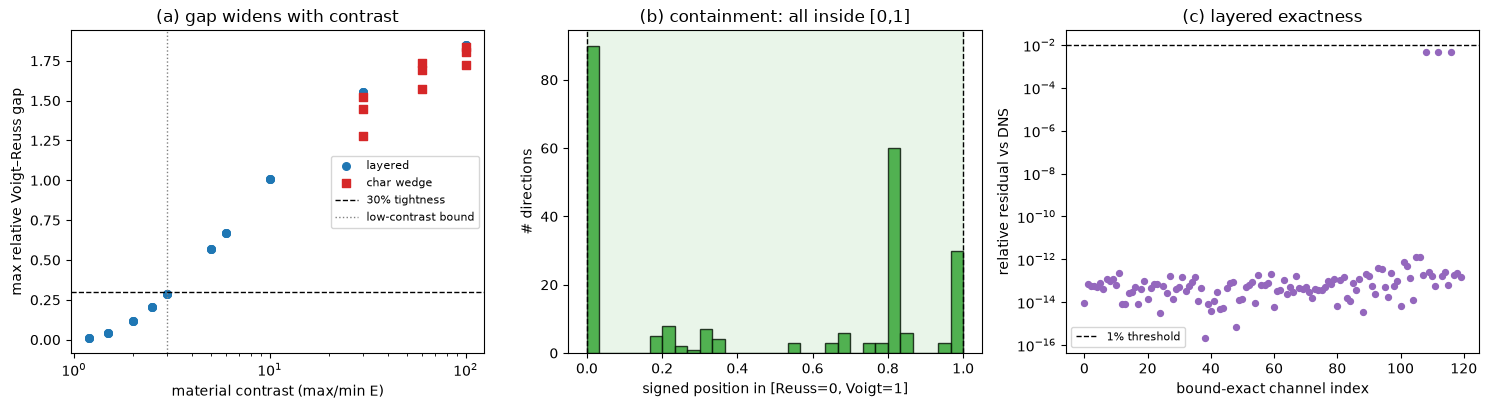

In [8]:
"""(8) Figures."""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) gap vs contrast
lay = [r for r in records if r["cell"].kind == "layered"]
chw = [r for r in records if r["cell"].kind == "char_wedge"]
ax[0].scatter([r["cell"].contrast for r in lay], [r["max_gap"] for r in lay],
              s=30, label="layered", color="tab:blue")
ax[0].scatter([r["cell"].contrast for r in chw], [r["max_gap"] for r in chw],
              s=30, marker="s", label="char wedge", color="tab:red")
ax[0].axhline(TIGHTNESS_GAP, ls="--", color="k", lw=1, label=f"{TIGHTNESS_GAP:.0%} tightness")
ax[0].axvline(LOW_CONTRAST_MAX, ls=":", color="gray", lw=1, label="low-contrast bound")
ax[0].set_xscale("log"); ax[0].set_xlabel("material contrast (max/min E)")
ax[0].set_ylabel("max relative Voigt–Reuss gap")
ax[0].set_title("(a) gap widens with contrast"); ax[0].legend(fontsize=8)

# (b) signed-position histogram (containment)
allsigned = np.concatenate([r["cont"]["signed"] for r in records])
ax[1].hist(allsigned, bins=30, color="tab:green", edgecolor="k", alpha=0.8)
ax[1].axvspan(0, 1, color="tab:green", alpha=0.10)
ax[1].axvline(0, ls="--", color="k", lw=1); ax[1].axvline(1, ls="--", color="k", lw=1)
ax[1].set_xlabel("signed position in [Reuss=0, Voigt=1]")
ax[1].set_ylabel("# directions")
ax[1].set_title("(b) containment: all inside [0,1]")

# (c) layered residuals vs 1% line
ax[2].scatter(range(len(res_vals)), np.maximum(res_vals, 1e-16),
              s=18, color="tab:purple")
ax[2].axhline(LAYERED_EXACT_TOL, ls="--", color="k", lw=1, label=f"{LAYERED_EXACT_TOL:.0%} threshold")
ax[2].set_yscale("log"); ax[2].set_xlabel("bound-exact channel index")
ax[2].set_ylabel("relative residual vs DNS")
ax[2].set_title("(c) layered exactness"); ax[2].legend(fontsize=8)

fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase0" / "results"
outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "V0_1_homogenization_bound.png", dpi=110)
print(f"saved figure -> {outdir / 'V0_1_homogenization_bound.png'}")
plt.show()


## (9) Determinism & frozen verdict

A spot-check that the DNS solve is bit-reproducible (protocol V0.5 discipline), then the pass/fail verdict against the three pre-registered thresholds and their declared failure-outcome classes.

In [9]:
"""(9) Determinism spot-check + frozen verdict."""
_c = battery[len(battery) // 2][1]
_a = effective_stiffness(_c.grid, _c.materials)
_b = effective_stiffness(_c.grid, _c.materials)
det_diff = float(np.abs(_a - _b).max() / np.abs(_a).max())
DETERMINISTIC = det_diff < DET_TOL
print(f"reproducibility: max rel diff on repeat solve = {det_diff:.2e}  "
      f"(< {DET_TOL:.0e} regime) -> {DETERMINISTIC}\n")

def verdict(name, passed, detail, fail_outcome):
    tag = "PASS" if passed else f"FAIL -> {fail_outcome}"
    print(f"  [{ 'OK ' if passed else 'XX '}] {name:34s} {tag}")
    print(f"        {detail}")

print("=" * 74)
print("V0.1 — HOMOGENIZATION BOUND VALIDITY & TIGHTNESS — VERDICT")
print("=" * 74)
verdict("1. containment (theorem, 100%)", METRIC1_PASS,
        f"{containment_frac*100:.4f}% directions in [Reuss,Voigt]; "
        f"PSD margin {worst_psd:.1e}", "KILL (theory/impl error)")
verdict("2. layered exactness (<1%)", METRIC2_PASS,
        f"max principal-direction residual {max_res:.1e}", "REDESIGN basis")
verdict("3. tightness (<30% for >80%)", METRIC3_PASS,
        f"{frac_tight:.0%} of {len(low)} low-contrast cells under {TIGHTNESS_GAP:.0%}",
        "REDESIGN (Hashin-Shtrikman / measured-RVE)")
verdict("(aux) oracle self-validated", ORACLE_OK,
        f"homog {homog_err:.1e}, backus {max(backus_errs):.1e}", "halt")
verdict("(aux) reproducible (V0.5 regime)", DETERMINISTIC,
        f"rel repeat diff {det_diff:.1e}", "see V0.5")

ALL_PASS = METRIC1_PASS and METRIC2_PASS and METRIC3_PASS and ORACLE_OK and DETERMINISTIC
print("=" * 74)
print(f"  V0.1 OVERALL: {'PASS — keystone holds; Phase-0 gate cleared for V0.1' if ALL_PASS else 'FAIL — see outcome class above'}")
print("=" * 74)


reproducibility: max rel diff on repeat solve = 0.00e+00  (< 1e-09 regime) -> True

V0.1 — HOMOGENIZATION BOUND VALIDITY & TIGHTNESS — VERDICT
  [OK ] 1. containment (theorem, 100%)     PASS
        100.0000% directions in [Reuss,Voigt]; PSD margin -1.3e-12
  [OK ] 2. layered exactness (<1%)         PASS
        max principal-direction residual 4.5e-03
  [OK ] 3. tightness (<30% for >80%)       PASS
        100% of 15 low-contrast cells under 30%
  [OK ] (aux) oracle self-validated        PASS
        homog 9.8e-14, backus 8.8e-14
  [OK ] (aux) reproducible (V0.5 regime)   PASS
        rel repeat diff 0.0e+00
  V0.1 OVERALL: PASS — keystone holds; Phase-0 gate cleared for V0.1
